# 01 · Spatial Dependence

Continuación del overview general, enfocada en medir y describir la dependencia espacial del precio por metro cuadrado en CABA.


## Objetivos

- Trabajar sobre el mismo subconjunto filtrado del overview.
- Medir autocorrelación espacial global del target.
- Estimar una escala espacial de referencia mediante el variograma.
- Evaluar la cobertura local de datos a esa escala.
- Mostrar evidencia descriptiva de heterogeneidad espacial en la relación entre superficie, ambientes y precio.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "01_spatial_dependence"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


## Carga de datos

Se replica la preparación básica del dataset de venta para que este notebook sea autosuficiente y comparable con el `overview`.


In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "processed"
rental_path = DATA_DIR / "arg_alquiler_data_processed.csv"
sale_path = DATA_DIR / "arg_venta_data_processed.csv"

with pd.option_context("display.max_columns", 200):
    df_rental = pd.read_csv(rental_path)
    df_sale = pd.read_csv(sale_path)

for dataset in (df_rental, df_sale):
    dataset["precio_sobre_m2"] = dataset["precio"] / dataset["area_m2_total"]

subset_config = {
    "sample_n": 5000,
    "sample_frac": None,
    "random_state": 42,
    "barrios": None,
    "splits": None,
    "active_only": False,
    "min_area_m2": None,
}

def build_sale_subset(df_source, config):
    subset = df_source.copy()
    applied_filters = []
    barrio_col = "barrio_right" if "barrio_right" in subset.columns else "barrio"

    if config["active_only"]:
        subset = subset.loc[subset["valido_hasta"].isna()].copy()
        applied_filters.append("solo publicaciones activas")

    if config["barrios"]:
        subset = subset.loc[subset[barrio_col].isin(config["barrios"])].copy()
        applied_filters.append(f"barrios={config['barrios']}")

    if config["splits"]:
        subset = subset.loc[subset["split"].isin(config["splits"])].copy()
        applied_filters.append(f"splits={config['splits']}")

    if config["min_area_m2"] is not None:
        subset = subset.loc[subset["area_m2_total"] >= config["min_area_m2"]].copy()
        applied_filters.append(f"area_m2_total>={config['min_area_m2']}")

    if config["sample_frac"] is not None:
        subset = subset.sample(
            frac=config["sample_frac"],
            random_state=config["random_state"],
        )
        applied_filters.append(f"sample_frac={config['sample_frac']}")
    elif config["sample_n"] is not None and len(subset) > int(config["sample_n"]):
        subset = subset.sample(
            n=int(config["sample_n"]),
            random_state=config["random_state"],
        )
        applied_filters.append(f"sample_n={int(config['sample_n'])}")

    subset = subset.reset_index(drop=True)

    if subset.empty:
        raise ValueError("El subconjunto quedó vacío. Ajustá subset_config.")

    return subset, applied_filters

# Dataset principal para análisis de venta.
df, subset_filters = build_sale_subset(df_sale, subset_config)
if "barrio" not in df.columns and "barrio_right" in df.columns:
    df["barrio"] = df["barrio_right"]
analysis_scope = "subconjunto configurado" if subset_filters else "dataset completo"
target_col = "precio_sobre_m2"
coord_cols = ["longitud", "latitud"]
id_col = "id" if "id" in df.columns else "id_left"

print("Dataset de alquileres (completo):", df_rental.shape)
print("Dataset de venta (completo):", df_sale.shape)
print(f"Dataset principal ({analysis_scope}):", df.shape)
print(f"Cobertura del subconjunto sobre venta: {len(df) / len(df_sale):.1%}")
if subset_filters:
    print("Filtros aplicados al dataset principal:")
    for step in subset_filters:
        print("-", step)
else:
    print("No se aplicaron filtros; el dataset principal usa todas las filas de venta.")
print("Columnas comunes entre ambos datasets:")
print(sorted(set(df_rental.columns) & set(df_sale.columns)))

print("Primeras filas del dataset principal:")
display(df.head(3))


Dataset de alquileres (completo): (3159, 95)
Dataset de venta (completo): (73613, 100)
Dataset principal (subconjunto configurado): (5000, 101)
Cobertura del subconjunto sobre venta: 6.8%
Filtros aplicados al dataset principal:
- sample_n=5000
Columnas comunes entre ambos datasets:
['Nombre', 'ambientes', 'ambientes_scaled', 'antiguedad', 'antiguedad_cat', 'antiguedad_scaled', 'apadrinada', 'area', 'area_m2_cubierta', 'area_m2_descubierta', 'area_m2_descubierta_scaled', 'area_m2_total', 'area_m2_total_scaled', 'area_metro', 'banos', 'banos_scaled', 'barrio_left', 'barrio_right', 'boletin_of', 'clasificac', 'cocheras', 'cocheras_scaled', 'comuna_left', 'comuna_right', 'decreto', 'disposicion', 'disposicion_Contrafrente', 'disposicion_Frente', 'disposicion_Interno', 'disposicion_Lateral', 'dist_areas_programaticas', 'dist_areas_programaticas_scaled', 'dist_avenida_rivadavia', 'dist_avenida_rivadavia_scaled', 'dist_espacio_verde', 'dist_espacio_verde_scaled', 'dist_est_educativo', 'dist_e

,idx,id_left,url,precio,moneda,expensas,tipo_unidad,area_m2_cubierta,area_m2_descubierta,area_m2_total,antiguedad,estado_edificio,ambientes,banos,estado,disposicion,orientacion,latitud,longitud,image_url,imagen_path,valido_desde,valido_hasta,cocheras,dormitorios,informacion_adicional,pozo,fecha_publicacion_aviso_dt,fecha_modificacion_aviso_dt,fecha_modificacion_puntos_dt,id_right,objeto,barrio_left,comuna_left,perimetro_,area_metro,antiguedad_cat,dist_subte,nearest_subte,dist_universidad,nearest_universidad,dist_hospital,nearest_hospital,dist_est_educativo,nearest_est_educativo,id_left.1,nombre_left,nom_mapa,barrio_right,comuna_right,ubicacion,clasificac,tiene_pati,apadrinada,decreto,fecha_decr,ordenanza_,fecha_orde,boletin_of,fecha_bole,area,perimetro,observacio,dist_espacio_verde,id_right.1,nombre_right,dist_areas_programaticas,Nombre,dist_avenida_rivadavia,n_universidades_1000m,n_robos_1000m,n_ventas_1000m_90d,velocidad_ventas_1000m_90d,estado_num,disposicion_Frente,disposicion_Contrafrente,disposicion_Lateral,disposicion_Interno,log_precio,area_m2_total_scaled,area_m2_descubierta_scaled,ambientes_scaled,banos_scaled,cocheras_scaled,antiguedad_scaled,expensas_scaled,estado_num_scaled,dist_subte_scaled,dist_universidad_scaled,dist_hospital_scaled,dist_est_educativo_scaled,dist_espacio_verde_scaled,dist_areas_programaticas_scaled,dist_avenida_rivadavia_scaled,n_robos_1000m_scaled,n_universidades_1000m_scaled,n_ventas_1000m_90d_scaled,velocidad_ventas_1000m_90d_scaled,split,precio_sobre_m2,barrio
0,26288,19218100.0,https://www.argenprop.com/departamento-en-vent...,250000.0,USD,0.0,NaN,60.0,0.0,0.0,20.0,0.0,2.0,1.0,NaN,Frente,NaN,-34.559735,-58.444818,https://www.argenprop.com/static-content/00181...,NaN,2026-04-11 05:46:02.319502,2026-04-20 23:15:09.548471,0.0,1.0,NaN,0.0,NaN,b'',b'',5.0,BARRIO,Belgrano,13.0,20430.59,8060009.10,20,983.450771,Jose Hernandez,511.555473,Universidad de Belgrano,2.218961e+06,Hospital Especializado de Gastroenterologia B....,188399.657445,Establecimiento educativo CARLOS PELLEGRINI,2226,NaN,NaN,Belgrano,13,AV VIRREY VERTIZ y JOSE HERNANDEZ,PLAZOLETA,NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.208709,69.659616,NaN,168.225933,6,Área Programática Hospital Dr. J. A. Fernandez,0.0,Avenida Rivadavia,7484.979607,4,157,18,0.200000,3.0,1,0,0,0,12.429220,-1.102816,-0.396052,-0.421744,-0.064945,-0.053375,-0.233498,-0.772924,-0.087307,-0.117881,-0.413979,-0.507993,0.066150,-0.327743,-0.225084,1.357064,-0.631163,-0.087421,-0.743568,-0.743568,train,inf,Belgrano
1,30521,18461075.0,https://www.argenprop.com/departamento-en-vent...,140000.0,USD,0.0,NaN,55.0,0.0,55.0,0.0,0.0,3.0,1.0,NaN,Frente,NaN,-34.646270,-58.520160,https://www.argenprop.com/static-content/57016...,NaN,2026-04-11 05:52:29.994537,2026-04-22 04:38:55.491288,0.0,2.0,NaN,0.0,NaN,b'',b'',15.0,BARRIO,Liniers,9.0,9256.93,4374419.15,0,4935.309836,San Pedrito,4932.947567,Universidad de Flores,2.229342e+06,Hospital Especializado de Gastroenterologia B....,180604.521931,Establecimiento educativo CARLOS PELLEGRINI,1142,Plaza Sarmiento,Pza. Sarmiento,Liniers,9,TUYUTI - COSQUIN - HUMAITA - EL RASTREADOR,PLAZA,SI,NO,NaN,NaN,3.952,NaN,2.234,NaN,4321.726337,901.126051,NaN,336.618411,10,Área Programática Hospital Donacion F. Santoj...,0.0,Avenida Rivadavia,996.810117,0,94,26,0.288889,3.0,1,0,0,0,11.849405,0.112684,-0.396052,0.438209,-0.064945,-0.053375,-1.143814,-0.772924,-0.087307,3.007694,4.071453,2.309151,-1.968297,0.734006,-0.225084,-0.818334,-1.150066,-0.661898,-0.609474,-0.609474,train,2545.454545,Liniers
2,90573,19374873.0,https://www.argenprop.com/departamento-en-vent...,130000.0,USD,280000.0,NaN,52.0,0.0,52.0,40.0,0.0,3.0,1.0,NaN,Frente,NaN,-34.566570,-58.472190,https://www.argenprop.com/static-content/37847...,NaN,2026-05-12 15:01:43.195002,NaN,0.0,2.0,3 AMBIENTES. TODO AL FRENTE. 52 M2. IMPECABLE....,0.0,2026-04-07T11:14:09Z,2026-04-24T10:11:53.567Z,2026-04-17T16:35:03.647Z,5.0,BARRIO,Belgrano,13.0,20430.59,8060009.10,40,1487.031332,Echeverría - Mártires Palotino

## Variable objetivo

Aplicamos el mismo recorte analítico usado en el overview: `log1p(precio_m2) < 9.2`. Esto evita que observaciones extremadamente caras dominen las métricas espaciales descriptivas.


Filtrado para el resto del analisis: log1p(precio_m2) < 9.2. Se conservaron 3,584 de 5,000 observaciones (71.7%).


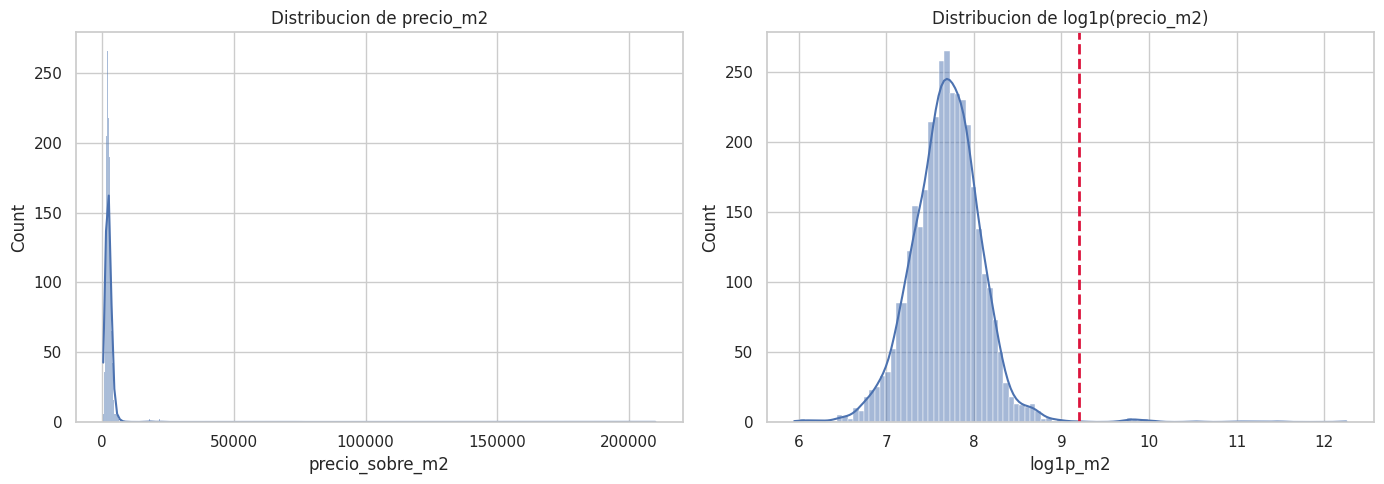

In [3]:
log1p_threshold = 9.2

df["log1p_m2"] = np.log1p(df[target_col])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df[target_col], kde=True, ax=axes[0])
axes[0].set_title("Distribucion de precio_m2")
sns.histplot(df["log1p_m2"], kde=True, ax=axes[1])
axes[1].axvline(log1p_threshold, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Distribucion de log1p(precio_m2)")
plt.tight_layout()

mask_log1p = np.isfinite(df["log1p_m2"]) & (df["log1p_m2"] < log1p_threshold)
n_before = len(df)
df = df.loc[mask_log1p].copy().reset_index(drop=True)

print(
    f"Filtrado para el resto del analisis: log1p(precio_m2) < {log1p_threshold}. "
    f"Se conservaron {len(df):,} de {n_before:,} observaciones ({len(df) / n_before:.1%})."
)


## Preparación espacial

Construimos el `GeoDataFrame` del subconjunto filtrado y cargamos el contorno de barrios para usarlo como referencia cartográfica en los análisis siguientes.


In [4]:
barrios = gpd.read_file(PROJECT_ROOT / "GeoData" / "barrios.geojson")

gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[coord_cols[0]], df[coord_cols[1]]),
    crs="EPSG:4326",
)

barrios = barrios.to_crs(gdf.crs)

print(f"Observaciones usadas para el análisis espacial: {len(gdf):,}")
print(f"Barrios con al menos una observación: {gdf['barrio'].nunique()}")


Observaciones usadas para el análisis espacial: 3,584
Barrios con al menos una observación: 48


## Mapa base del target

Antes de pasar a métricas formales, conviene mirar el target sobre el mapa de CABA para ubicar visualmente gradientes y focos de concentración.


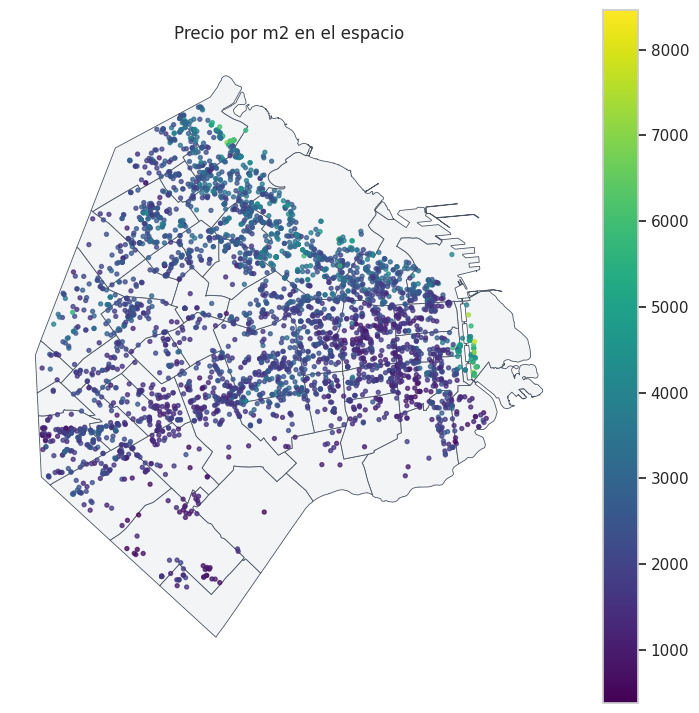

In [5]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[coord_cols[0]], df[coord_cols[1]]),
    crs="EPSG:4326",
)

barrios_plot = barrios.to_crs(gdf.crs)
fig, ax = plt.subplots(figsize=(9, 9))
barrios_plot.plot(
    ax=ax,
    edgecolor="#4b5563",
    facecolor="#f3f4f6",
    linewidth=0.6,
)
gdf.plot(
    ax=ax,
    column=target_col,
    cmap="viridis",
    alpha=0.75,
    markersize=8,
    legend=True,
)
ax.set_title("Precio por m2 en el espacio")
ax.set_axis_off()


## Análisis de correlación espacial


Calculamos el índice de Moran global y su prueba por permutaciones para verificar si `precio_m2` exhibe autocorrelación espacial positiva más allá de lo esperable por azar.


In [6]:
import libpysal
from esda.moran import Moran

w = libpysal.weights.Queen.from_dataframe(gdf)
w.transform = 'R'  # Row-standardize weights for Moran's I calculation

# 3. Calculate Global Moran's I for a specific attribute/column
y = gdf['precio_sobre_m2'].values
moran = Moran(y, w)

# 4. Access results
print(f"Moran's I Statistic: {moran.I}")
print(f"P-value: {moran.p_sim}")  # Simulated p-value (standard for significance)
print(f"Z-score: {moran.z_sim}")

indice_de_moran_global = moran.I

Moran's I Statistic: 0.5824228018962665
P-value: 0.001
Z-score: 65.90642331299259


/home/saneliges/Escritorio/caba-property-opportunities/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_868768/4223692858.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf)


## Variograma y escala espacial de referencia

Reproyectamos a un CRS métrico y estimamos un variograma del precio por metro cuadrado. El `range_` resultante se usa luego como escala de referencia para estudiar densidad y cobertura local.


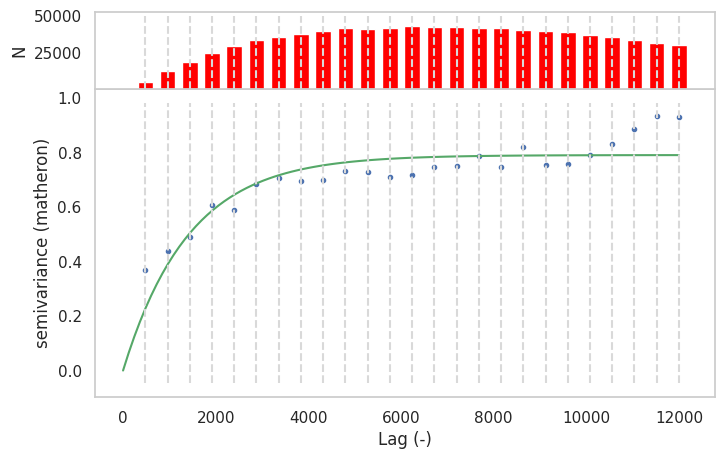

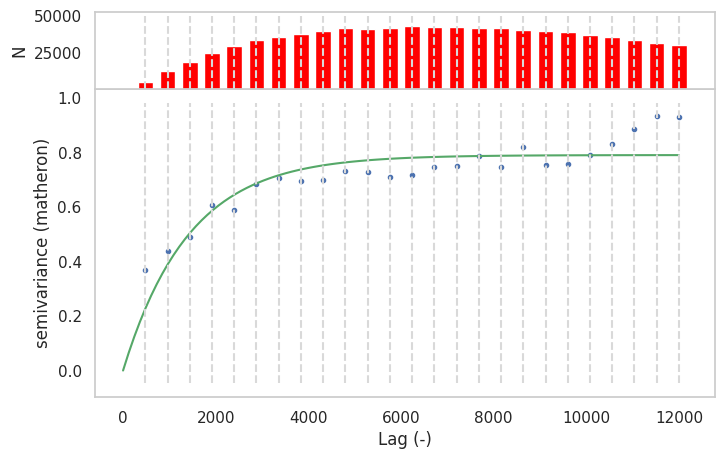

In [7]:
# Reproyeccion a CRS metrico para usar distancias (metros)
from shapely import Point, unary_union
from skgstat import Variogram


gdf_m = (gdf
         .to_crs(epsg=3857)
         .sample(frac=0.4, random_state=42) ) # submuestra del 40% para que el análisis sea más rápido
barrios_m = gpd.read_file(PROJECT_ROOT / "GeoData" / "barrios.geojson").to_crs(gdf_m.crs)
caba_polygon = unary_union(barrios_m.geometry)

xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 300

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])

gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf_m.crs
)

gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])

# Target: precio por m2
precio_por_m2 = gdf_m["precio"] / gdf_m["area_m2_total"]

mask = (
    np.isfinite(precio_por_m2) &
    (gdf_m["area_m2_total"] >= 15)
)

# Coordenadas y variable (en metros)
x = gdf_m.geometry.x.values[mask]
y = gdf_m.geometry.y.values[mask]
v = precio_por_m2.values[mask]

coords = np.column_stack([x, y])

# Si hay coords duplicadas exactas, el variograma/kriging pueden fallar.
# Jitter minimo en metros solo para esas filas (reproducible).
np.random.seed(42)
_, uniq_counts = np.unique(coords, axis=0, return_counts=True)
if (uniq_counts > 1).any():
    # identificamos duplicados de forma simple por hashing
    import pandas as _pd
    _dfc = _pd.DataFrame(coords, columns=["x", "y"])
    dup_mask = _dfc.duplicated(subset=["x", "y"], keep=False).to_numpy()
    coords[dup_mask, 0] += np.random.normal(0, 1.0, size=dup_mask.sum())
    coords[dup_mask, 1] += np.random.normal(0, 1.0, size=dup_mask.sum())
    x = coords[:, 0]
    y = coords[:, 1]

V = Variogram(
    coords,
    v,
    model="exponential",
    n_lags=25,
    maxlag=12000
)

range_ = V.parameters[0]
sill = V.parameters[1]
nugget = V.parameters[2]

V.plot()


## Densidad espacial a escala del variograma

Tomamos el `range_` estimado por el variograma como escala espacial de referencia. Con esa distancia construimos radios de `1x`, `2x` y `3x` el `range_` y medimos, para cada publicación, cuántos departamentos quedan dentro de ese entorno.

Además de la cantidad promedio de vecinos, reportamos una densidad media en `dptos/km` para seguir una lectura lineal del radio y una densidad en `dptos/km²`, más interpretable desde el punto de vista espacial. La comparación entre mínimos, máximos y percentiles permite evaluar cuán heterogénea es la cobertura de datos en la ciudad.


In [8]:
from scipy.spatial import cKDTree

gdf_density = gdf.to_crs(epsg=3857).copy()
density_mask = (
    np.isfinite(gdf_density["precio"]) &
    np.isfinite(gdf_density["area_m2_total"]) &
    (gdf_density["area_m2_total"] >= 15)
)
gdf_density = gdf_density.loc[density_mask].copy()

coords_density = np.column_stack([
    gdf_density.geometry.x.to_numpy(),
    gdf_density.geometry.y.to_numpy(),
])
density_tree = cKDTree(coords_density)

range_km = range_ / 1000
radius_multipliers = np.array([1.0, 2.0, 3.0])
radius_values_m = range_ * radius_multipliers

local_neighbor_counts = {}
density_summary_rows = []

for multiplier, radius_value_m in zip(radius_multipliers, radius_values_m):
    neighborhood_lists = density_tree.query_ball_point(coords_density, r=radius_value_m)
    counts = np.fromiter(
        (len(neighbor_ids) - 1 for neighbor_ids in neighborhood_lists),
        dtype=int,
        count=len(neighborhood_lists),
    )
    local_neighbor_counts[float(multiplier)] = counts

    radius_value_km = radius_value_m / 1000
    circle_area_km2 = np.pi * radius_value_km**2
    counts_per_km = counts / radius_value_km
    counts_per_km2 = counts / circle_area_km2

    p05 = np.percentile(counts, 5)
    p95 = np.percentile(counts, 95)
    min_count = counts.min()
    max_count = counts.max()

    density_summary_rows.append({
        "multiplo_range": float(multiplier),
        "radio_km": radius_value_km,
        "vecinos_promedio": counts.mean(),
        "vecinos_mediana": np.median(counts),
        "vecinos_min": min_count,
        "vecinos_max": max_count,
        "p05_vecinos": p05,
        "p95_vecinos": p95,
        "ratio_max_min": np.nan if min_count == 0 else max_count / min_count,
        "ratio_p95_p05": np.nan if p05 == 0 else p95 / p05,
        "cv_vecinos": np.std(counts) / max(np.mean(counts), 1e-9),
        "dptos_por_km_promedio": counts_per_km.mean(),
        "dptos_por_km2_promedio": counts_per_km2.mean(),
    })

density_summary = pd.DataFrame(density_summary_rows)
display(density_summary.round(3))

,multiplo_range,radio_km,vecinos_promedio,vecinos_mediana,vecinos_min,vecinos_max,p05_vecinos,p95_vecinos,ratio_max_min,ratio_p95_p05,cv_vecinos,dptos_por_km_promedio,dptos_por_km2_promedio
0,1.0,4.259,816.188,828.0,56,1391,363.0,1291.9,24.839,3.559,0.349,191.631,14.322
1,2.0,8.518,2100.247,2141.0,500,3110,1029.3,2965.0,6.220,2.881,0.287,246.557,9.213
2,3.0,12.777,3134.077,3269.0,1422,3582,2230.0,3582.0,2.519,1.606,0.144,245.281,6.110


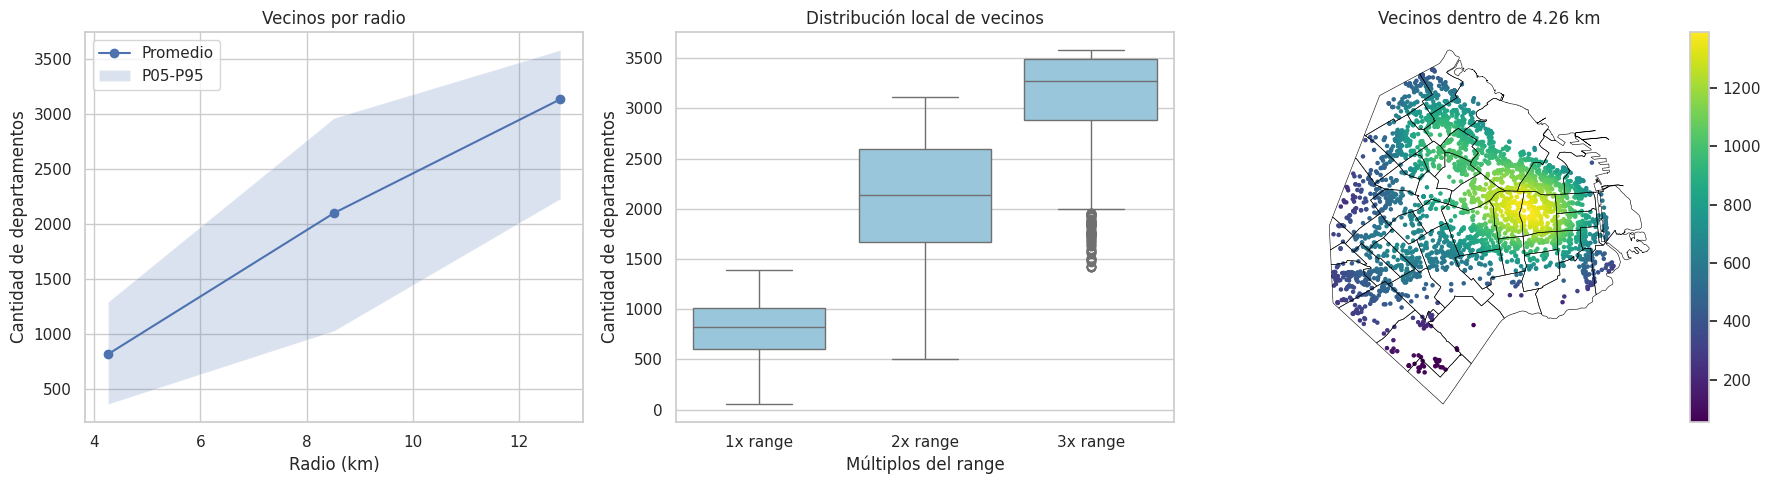

Range estimado del variograma: 4.26 km
A 1x range, cada departamento tiene en promedio 816.2 vecinos, con un mínimo de 56 y un máximo de 1391.
La densidad media en esa escala es 191.63 dptos/km y 14.32 dptos/km².
Como criterio descriptivo, el ratio P95/P05 es 3.56 y el coeficiente de variación es 0.35, lo que sugiere una heterogeneidad alta en la cobertura espacial.
Esta lectura es descriptiva: para hablar de significancia estadística haría falta una prueba espacial formal o simulaciones de referencia.


In [9]:
selected_multiplier = 1.0
selected_radius_km = range_km * selected_multiplier
selected_column = "vecinos_en_1x_range"
gdf_density[selected_column] = local_neighbor_counts[selected_multiplier]

density_long = pd.DataFrame({
    f"{multiplier:.0f}x range": counts
    for multiplier, counts in local_neighbor_counts.items()
})
density_long = density_long.melt(var_name="radio", value_name="vecinos")

barrios_density = barrios.to_crs(gdf_density.crs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(density_summary["radio_km"], density_summary["vecinos_promedio"], marker="o", label="Promedio")
axes[0].fill_between(
    density_summary["radio_km"],
    density_summary["p05_vecinos"],
    density_summary["p95_vecinos"],
    alpha=0.2,
    label="P05-P95",
)
axes[0].set_title("Vecinos por radio")
axes[0].set_xlabel("Radio (km)")
axes[0].set_ylabel("Cantidad de departamentos")
axes[0].legend()

sns.boxplot(data=density_long, x="radio", y="vecinos", ax=axes[1], color="#8ecae6")
axes[1].set_title("Distribución local de vecinos")
axes[1].set_xlabel("Múltiplos del range")
axes[1].set_ylabel("Cantidad de departamentos")

barrios_density.boundary.plot(ax=axes[2], color="black", linewidth=0.4)
gdf_density.plot(
    ax=axes[2],
    column=selected_column,
    cmap="viridis",
    markersize=5,
    legend=True,
)
axes[2].set_title(f"Vecinos dentro de {selected_radius_km:.2f} km")
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

reference_row = density_summary.iloc[0]
if reference_row["ratio_p95_p05"] >= 2 or reference_row["cv_vecinos"] >= 0.5:
    heterogeneity_label = "alta"
elif reference_row["ratio_p95_p05"] >= 1.5 or reference_row["cv_vecinos"] >= 0.3:
    heterogeneity_label = "moderada"
else:
    heterogeneity_label = "acotada"

print(f"Range estimado del variograma: {range_km:.2f} km")
print(
    f"A 1x range, cada departamento tiene en promedio {reference_row['vecinos_promedio']:.1f} vecinos, "
    f"con un mínimo de {int(reference_row['vecinos_min'])} y un máximo de {int(reference_row['vecinos_max'])}."
)
print(
    f"La densidad media en esa escala es {reference_row['dptos_por_km_promedio']:.2f} dptos/km "
    f"y {reference_row['dptos_por_km2_promedio']:.2f} dptos/km²."
)
print(
    f"Como criterio descriptivo, el ratio P95/P05 es {reference_row['ratio_p95_p05']:.2f} "
    f"y el coeficiente de variación es {reference_row['cv_vecinos']:.2f}, lo que sugiere una heterogeneidad {heterogeneity_label} en la cobertura espacial."
)
print("Esta lectura es descriptiva: para hablar de significancia estadística haría falta una prueba espacial formal o simulaciones de referencia.")

## Dependencias espaciales complejas

El precio por metro cuadrado no sigue el mismo patrón en todos los barrios. La relación entre superficie, ambientes y precio cambia localmente, lo que sugiere no linealidades con fuerte heterogeneidad espacial.

A continuación se grafican relaciones entre `log_precio` y `area_m2_total` para distintos barrios. Cada línea de color resume la pendiente estimada para una cantidad de ambientes.

Se observan patrones distintos según la zona: en algunos barrios los monoambientes amplios parecen valorizarse más por m² que unidades de dos ambientes, mientras que en otros ocurre lo contrario.

Esta lectura refuerza la necesidad de modelos con un inductive bias compatible con relaciones no lineales y dependencia espacial.


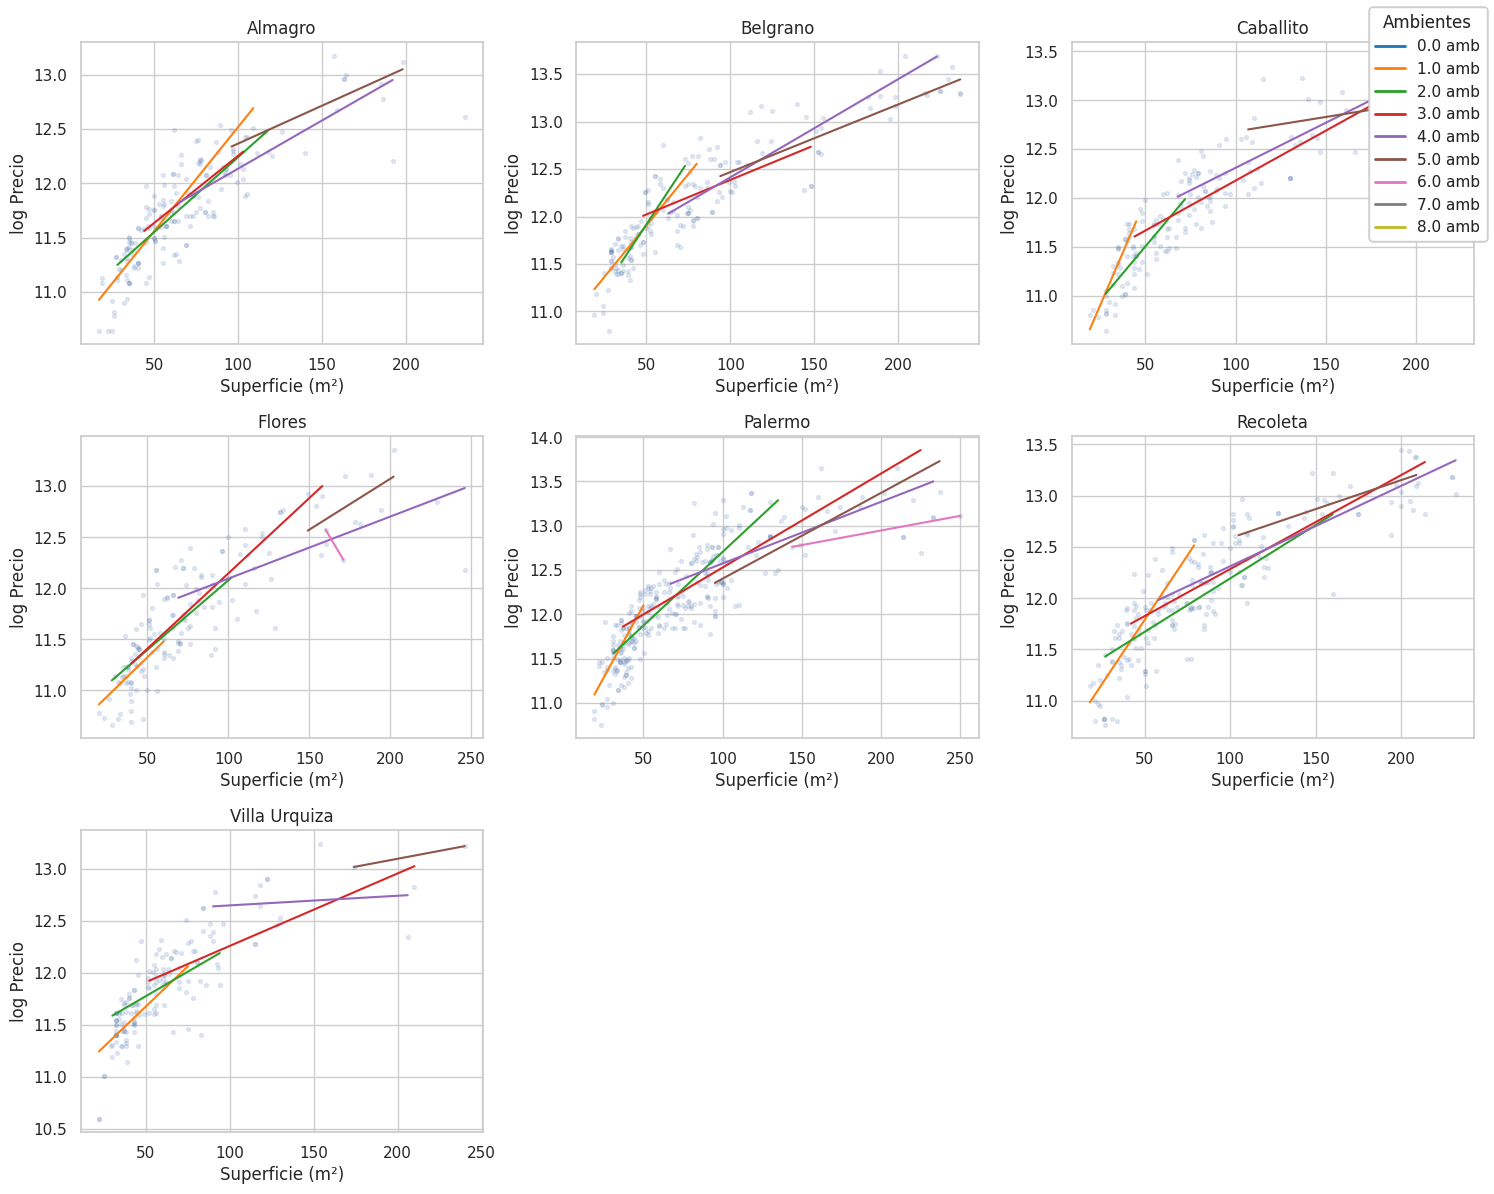

In [10]:
min_obs = 150

barrios_con_observaciones = (
    gdf
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf['area_m2_total'].min()
xmax = 400

ymin = gdf['log_precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf[gdf['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2_total'],
        gdf_b['log_precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(sub['area_m2_total'])
        y = sub['log_precio']

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2_total'].min(),
            sub['area_m2_total'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(x_grid)
        )

        ax.plot(
            x_grid,
            y_hat,
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('log Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Conclusiones

- El precio por metro cuadrado muestra dependencia espacial global: no se distribuye de manera independiente en el espacio urbano.
- El variograma sugiere una escala espacial de referencia útil para pensar vecindad, cobertura local y efectos de contexto.
- La densidad de observaciones no es homogénea en toda la ciudad, por lo que la calidad de la señal espacial cambia según la zona.
- La relación entre superficie, ambientes y precio no parece estable entre barrios, lo que refuerza la hipótesis de heterogeneidad espacial y no linealidad.
- En conjunto, estos resultados justifican evaluar modelos con inductive bias espacial o, al menos, estrategias que incorporen explícitamente contexto geográfico local.
